<div style="margin: 0 auto 20px; height: 70px; border: 2px solid gray; border-radius: 6px;">
  <div style="float: left; margin: 4px 0;"><img src="img/epfl.png" /></div>
  <div style="float: right; margin: 20px 30px 0; font-size: 13pt; font-weight: bold; font-family: Segoe UI;"><a href="https://moodle.epfl.ch/course/view.php?id=18253">COM202 - Signal Processing</a></div>
</div>
<div style="clear: both; font-size: 30pt; font-weight: bold; font-family: Cooper Black; color: #483D8B;">
    Fun with Filters
</div>

In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import IPython

In [2]:
plt.rcParams['figure.figsize'] = 14, 4 
DEFAULT_SF = 32000

In [3]:
def plot_response(t, x, ylabel='', color='C0', sub=None, label=None, xlabel='time [$s$]'):
    ax = plt.subplot(*sub) if sub is not None else plt.subplot()
    plt.plot(t, x, color, lw=3, label=label)
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.grid()

In [4]:
def plot_response(t, x, ylabel='', color='C0', sub=None, label=None, xlabel='time [$s$]'):
    ax = plt.subplot(*sub) if sub is not None else plt.subplot()
    plt.plot(t, x, color, lw=3, label=label)
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.grid()

# What is a filter?

A filter is a device (or material) used to modify an input quantity by holding back some of its components.  

## Etymologically...
<img src="img/airfilter.jpg" alt="Drawing" style="float: right; width: 500px; margin: 0px 30px;"/>

The word "filter" comes from "felt", a type of thick, porous fabric used as a sieve for liquids.


<img src="img/tips.jpg" alt="Drawing" style="float: lefti; width: 200px; margin: 30px 30px;"/>



## Acoustic filters
<img src="img/earplugs1.jpg" alt="Drawing" style="float: left; width: 300px; margin: 100px 30px;"/>
<img src="img/earplugs2.jpg" alt="Drawing" style="float: right; width: 300px; margin: 100px 30px;"/>


## Mechanical filters

<img src="img/shockabsorber.jpg" alt="Drawing" style="float: left; width: 500px; margin: 100px 30px;"/>

## Optical filters

<img src="img/3dglasses.png" alt="Drawing" style="float: left; width: 500px; margin: 100px 30px;"/>

## Electronic filters

<img src="img/crossover.jpg" alt="Drawing" style="float: left; width: 500px; margin: 100px 30px;"/>

## Digital filters

<img src="img/biquad.png" alt="Drawing" style="float: left; width: 600px; margin: 100px 30px;"/>

# Passive electronic filters

The theory of electronic filters developed at the beginning of the 20th century when engineers tried to overcome the difficulties of sending electrical signals over longer and longer wires. A long wire:
 * has an intrinsic resistence causing attenuation (understood at the time)
 * has a _distributed capacitance_ (not fully understood at the time)

The net result is that a long wire is equivalent to a lowpass filter.

## The telegraph system
<img src="img/telegraph.jpg" alt="Drawing" style="float: right; width: 400px; margin: 0px 0px;"/>

A basic telegraph system is just an ON/OFF circuit over a long wire. First demonstrated in 1844.

Detection can be performed acoustically, visually (lamp, needle or trace on paper)

Things are simple as long as the wire is not too long...

### Let's build a Morse-code transmitter

In [5]:
def morse(msg, wpm=50, sf=DEFAULT_SF):
    # using PARIS timing values:
    DIT = int(sf * 60 / (50 * wpm)) # dot
    DAH = 3 * DIT  # dash
    ISS = 1 * DIT  # intra-symbol space
    ICS = 3 * DIT  # inter-character space
    IWS = 7 * DIT  # inter-word space
    DICT = { 
        'A':'.-', 'B':'-...','C':'-.-.', 'D':'-..', 'E':'.', 'F':'..-.', 'G':'--.', 'H':'....', 'I':'..', 'J':'.---', 
        'K':'-.-', 'L':'.-..', 'M':'--', 'N':'-.', 'O':'---', 'P':'.--.', 'Q':'--.-', 'R':'.-.', 'S':'...', 'T':'-',
        'U':'..-', 'V':'...-', 'W':'.--', 'X':'-..-', 'Y':'-.--', 'Z':'--..', '1':'.----', '2':'..---', '3':'...--', 
        '4':'....-', '5':'.....', '6':'-....', '7':'--...', '8':'---..', '9':'----.', '0':'-----', ', ':'--..--', 
        '.':'.-.-.-', '?':'..--..', '/':'-..-.', '-':'-....-', '(':'-.--.', ')':'-.--.-'}
    
    # crude upper bound on number of samples
    x, ix = np.zeros(30 * DIT * len(msg), dtype=float), 0
    for c in msg.upper():
        if c == ' ':
            ix += IWS
        else:
            for d in DICT[c]:
                h = DIT if d == '.' else DAH
                x[ix:ix+h] = 1
                ix = ix + h + ISS
            ix += ICS
    return np.linspace(0, ix / sf, ix), x[:ix]

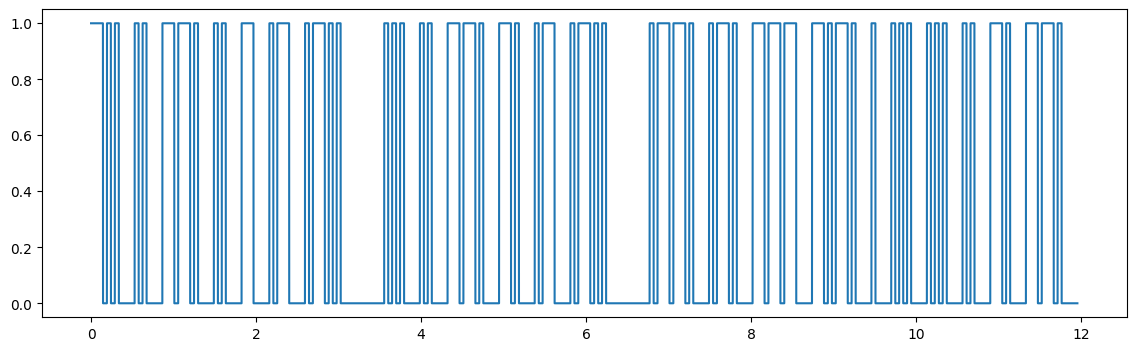

In [6]:
t = morse("Digital Signal Processing", wpm=25)
plt.plot(*t);

In [7]:
IPython.display.Audio(t[1], rate=DEFAULT_SF)

In [8]:
from IPython.display import YouTubeVideo
id='YPsgEdmlUf0?t=12'
YouTubeVideo(id=id,width=600,height=300)

### Sending telegrams from Europe to America

In the 1860 the first telegraph cables were laid between Europe and the US (~3000 km)

Although unknown at the time, such a long cable acts as a lowpass filter with a cutoff frequency $\approx 0.2~\mathrm{Hz}$

### Simulating the telegraph cable with a leaky integrator

Useful approximation for a leaky integrator with cutoff $f_c$ working at $F_s$ samples per second:

$$
    \lambda \approx e^{-2\pi f_c/F_s}
$$

### See what happens at the other end

In [9]:
def test_wpm(wpm, fc=0.2, sf=DEFAULT_SF, msg="Digital Signal Processing"):
    n, t = morse(msg, wpm=wpm)
    lam = np.exp(-2 * np.pi * fc / DEFAULT_SF)
    rt = signal.lfilter([1-lam], [1, -lam], t)
    plt.plot(n, t, 'gray')
    plt.plot(n, rt)
    return rt

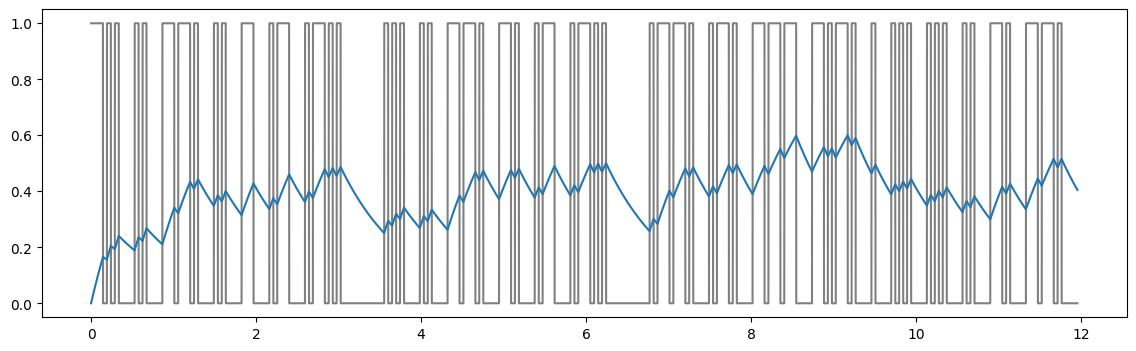

In [10]:
rt = test_wpm(25)

In [11]:
IPython.display.Audio(rt, rate=DEFAULT_SF)

### How slow do we have to transmit?

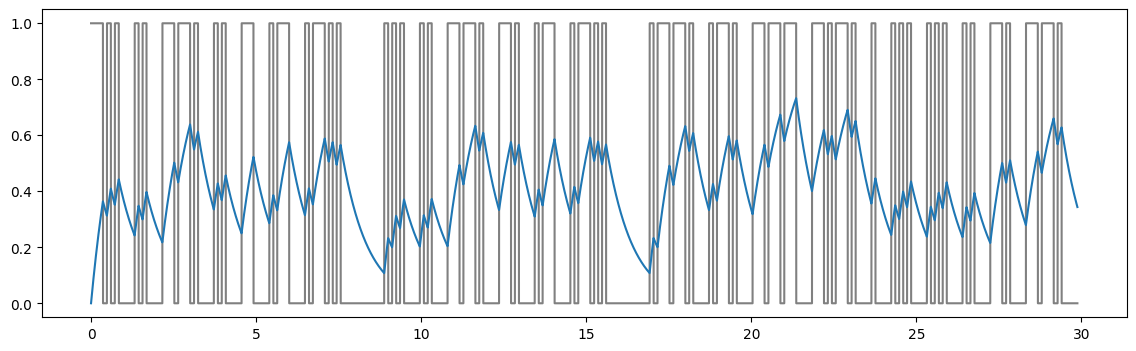

In [12]:
test_wpm(10);

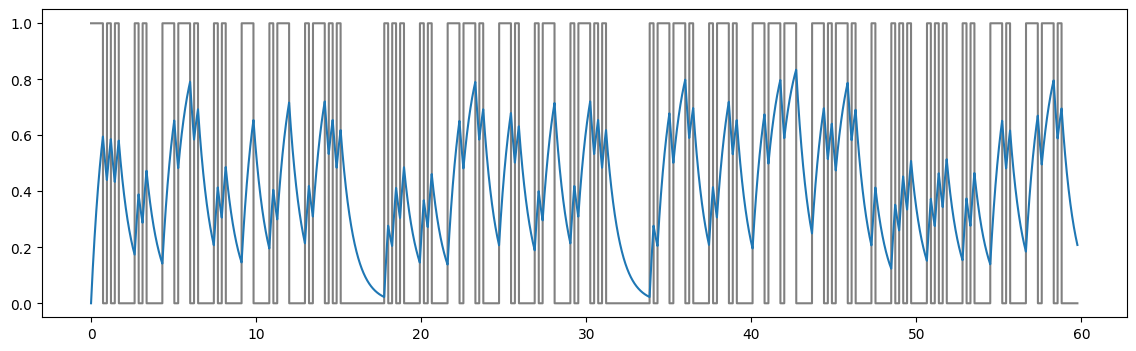

In [13]:
test_wpm(5);

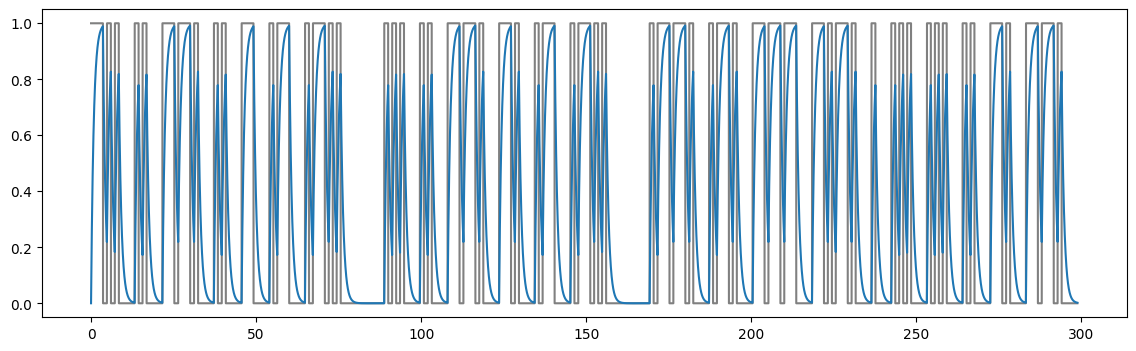

In [14]:
test_wpm(1);

# Continuous-time filters

## Analog signals and rate of change

 * analog signals: $x(t)$
   * $t$ expressed in seconds
   * $x$ expressed in physical units (meters, volts, amperes, pascals, etc.)
 * **rate of change** (how fast a signal increases or decreases over time) is the first derivative $x'(t) = d x/ d t$
   * if $x(t)$ is a position (in meters), $x'(t)$ is the _speed_ (in $\mathrm{m/s}$)
   * if $x(t)$ is an electrical charge (in coulomb), $x'(t)$ is the _current_ (in amperes)
   * if $x(t)$ is a liquid's volume (in $\mathrm{m^3}$), $x'(t)$ represents the _flow_ (in $\mathrm{m^3/s}$) 

## Memoryless and feedback systems

 * input: $x(t)$; output $y(t)$
 * in memoryless systems $y(t)$ depends only on $x(t)$
 * in feedback systems $y(t)$ depends also on past values of $x(t)$ and $y(t)$

## Intuitive examples: house plumbing

<div style="float: right; margin: 10px;"><img src="img/tap.jpg" width="180"></div>

### Memoryless system: the faucet

 * $\rho$ is the maximum flow provided by your plumbing system
 * faucet flow is an instantaneous function of the handle position $0 le a(t) le 1$
$$
    r(t) = \rho a(t) \qquad [\mathrm{m}^3/\mathrm{s}].
$$

### System with memory: the bathtub

<div style="float: right; margin: 10px;"><img src="img/bathtub.jpg" width="250"></div>

 * $r(t) = \rho a(t)$ is the flow from the faucet
 * $v(t)$ is the volume of water in the tub; starting from an empty tub:
$$
    v(t) = \int_0^t r(s)ds\qquad [\mathrm{m}^3];
$$
or
$$
    v'(t) = r(t) \qquad [\mathrm{m}^3/\mathrm{s}];
$$
 * the _rate of change_ of the water volume in the tub is equal to the instantaneous flow from the faucet

## The flush toilet as a feedback system
<div style="float: right; margin: 10px;"><img src="img/toilets.jpg" width="300"></div>

How it works:
 * a water tank containing $v(t)~\mathrm{m}^3$ of water, that can empty quickly
 * a tap with flow $r(t)$ that refills the tank to a maximum fill level $V_M$
 * a floating device that closes the tap as the level in the tank rises; assume the tap closes proportionally to accumulated water in the tank:
$$
     a(t) = \frac{V_M - v(t)}{V_M}.  \tag{1}
$$
    * when the tank is completely empty, tap is fully open: $v(t)=0 \Longrightarrow a(t) = 1$
    * when the tank is full, tap is shut off: $v(t)=V_M \Longrightarrow a(t)=0$ 
<center>
  <img src="img/ballcock.png" width="500"/>
  <div style="clear: both;"></div>
  <a href="https://commons.wikimedia.org/w/index.php?curid=10404250">source</a>
</center>

### How a toilet works, using differential equations

Again, with $v(t)$ the amount of water in the tank over time and $V_M$ be the maximum fill level, we can model the refilling process after flushing like so:

 * tap flow rate is $r(t) = \rho a(t)$
 * $a(t)$ decreases linearly with water level, $a(t) = 1 - v(t)/V_M$
 * as for a bathtub, the _rate of change_ of water volume is equal to the flow, $v'(t) = r(t) = \rho a(t)$.

The flush toilet is therefore described by a a linear, first-order differential equation
$$
  v'(t) = \rho - (\rho/V_M)\,v(t) \tag{2}
$$

### Standard solution 

The first-order ODE is easily solved ([details](https://en.wikipedia.org/wiki/Linear_differential_equation#Homogeneous_equation_with_constant_coefficients)) as

$$
  v(t) = V_M(1 - e^{-t/\tau}), \quad \tau = V_M/\rho
$$

We can plug in some realistic values and plot the evolution of the amount of water in the tank, as well as the flow from the tap over time:

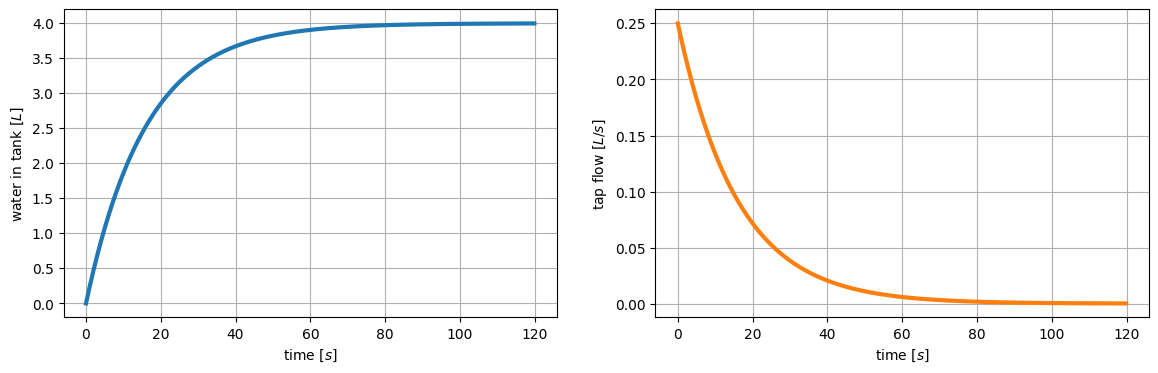

In [15]:
VM = 4       # less than 6 liters, as per European regulations!
rho = 15/60  # 15 l/m is good household tap flow

t = np.arange(0, 120, 0.1)           # two minutes
v = VM * (1 - np.exp(-rho/VM * t))   # tank level
a = rho * (VM - v) / VM              # tap flow

plot_response(t, v, 'water in tank [$L$]', 'C0', (1, 2, 1))
plot_response(t, a, 'tap flow [$L/s$]', 'C1', (1, 2, 2))


## A discrete-time toilet

Let's pretend the refilling takes place in discrete steps of duration $T$ seconds; at each step $n$:
 * the water level increases by a finite amount $d[n] = v[n] - v[n-1]$
 * $d[n]$ is the tap flow over $T$ seconds: $d[n] = Tr[n]$ 
 * flow over $T$ is constant and proportional to initial level: $r[n] = \rho (V_M - v[n-1])/V_M$ 

CCDE describing the system 
$$
    v[n] - v[n-1] = d[n] = Tr[n] = T(\rho/V_M)(V_M - v[n-1])
$$

discrete-time filling process
$$
    v[n] = (1-\lambda)V_M + \lambda v[n-1], \qquad \lambda = 1 - T/\tau,\quad  \tau = V_M/\rho ~~~[\mathrm{s}]
$$

### A toilet is a leaky integrator!

Let's compare:
 * the continuous-time water level curve; and
 * the discrete-time approximation using finer and finer discretization intervals

In [16]:
def dt_t(T, t_end=120, VM=4, rho=15/60):
    lam = 1 - T * rho / VM 
    N = int(t_end / T + 0.5) + 1
    v = np.zeros(N)
    for n in range(1, N):
        v[n] = (1 - lam) * VM + lam * v[n-1]
    return np.arange(0, N) * T, v

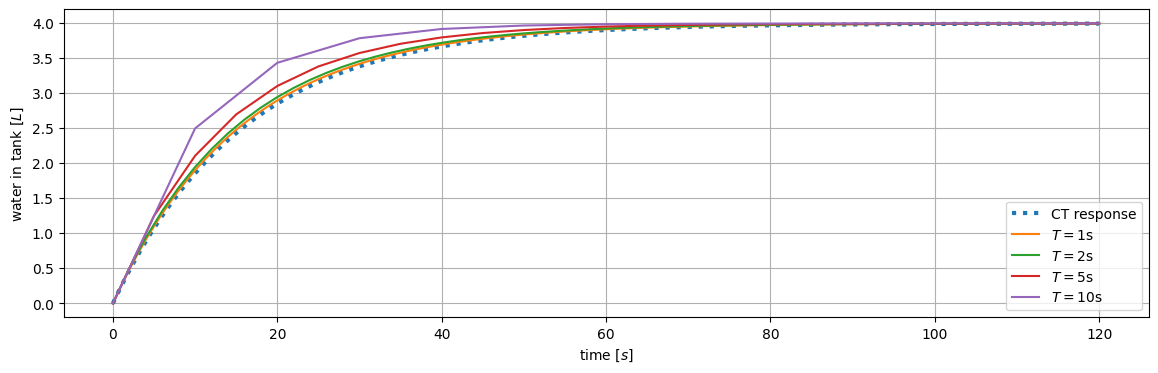

In [17]:
T_max = 120

VM, rho = 4, 15/60  # toilet parameters like before

t = np.arange(0, T_max, 0.01)
v = VM * (1 - np.exp(-t/(VM / rho)))   # tank level
plot_response(t, v, 'water in tank [$L$]', 'C0:', label='CT response')

for n, step in enumerate([1, 2, 5, 10]): #[30, 20, 10, 5]):
    plt.plot(*dt_t(step, T_max, VM, rho), f'C{n+1}', label=f"$T={step}$s")
plt.legend();

## Other analog feedback systems (that you can talk about at dinner)

 * heat loss (Newton, 1701), where $h(t)$ is the temperature in Celsius:
 $$
     h'(t) = K(T_e - h(t)) \quad 
 $$
 * radioactive decay, where $q(t)$ is the amount of substance:
 $$
     q'(t) = \lambda \, q(t)
 $$
 * the RC lowpass

# The RC lowpass filter

A long wire is equivalent to a resistor-capacitor (RC) lowpass filter.

<img src="img/rc.png" alt="Drawing" style="float: left; width: 500px; margin: 50px 300px;"/>

## The capacitor
<img src="img/capacitor.jpg" alt="Drawing" style="float: right; width: 300px; margin: 0px 30px;"/>

A capacitor is a device that can **store** energy by accumulating charges and creating an electric field

 * discovered in 1746 (the Leyden jar)
 * basically used as a battery until the development of radio

### Capacitance (Farads)

$$
    Q = CV
$$

<br>
energy stored:
$$
    E_C = \frac{1}{2}CV^2
$$

### Dynamic behavior

$$
    \frac{\partial Q}{\partial t} = C\frac{\partial V}{\partial t} \quad \Rightarrow \quad i(t) = C v'(t)
$$

### Hydraulic analogy

<img src="img/Capacitor-animation.gif" alt="Drawing" style="width: 800px; margin: 0px 30px;"/>

<i><small>Image by KDS4444 - Own work, CC BY-SA 4.0, https://commons.wikimedia.org/w/index.php?curid=64021013</small></i>

## The RC lowpass filter

<img src="img/rc.png" alt="Drawing" style="float: right; width: 300px; margin: 0px 30px;"/>

differential equation:
$$
\begin{align*}
    v_\mathrm{out}(t) &= v_\mathrm{in}(t) - Ri(t) &\qquad \mbox{(voltage drop on resistor)}\\
                      &= v_\mathrm{in}(t) - RCv_\mathrm{out}'(t)  &\qquad \mbox{(current is the same on R and C)}\\
\end{align*}
$$

<br>
using the Laplace transform:

$$
    V_\mathrm{out}(s) = \frac{1}{RCs + 1}V_\mathrm{in}(s)\qquad \mbox{(transfer funcion)}\\
$$


### RC circuit analysis

<div style="float: right; margin: 10px;"><img src="img/RC1.jpg" width="300"></div>

 * when the switch is closed, the current through the resistor is the same as through the capacitor: $i_R(t) = i_C(t)$
 * capacitor and resistor are connected in parallel so the voltage across them is the same: $v_R(t) = v_C(t)$
 * from Ohm's law, $v_C(t) = v_R(t) = Ri(t) = RCv_C'(t)$

$$
    v_C(t) - RC v'_c(t) = 0 \Longrightarrow v_C(t) = V_0\,e^{-t/\tau} \qquad\mbox{time constant $\tau = RC$}
$$

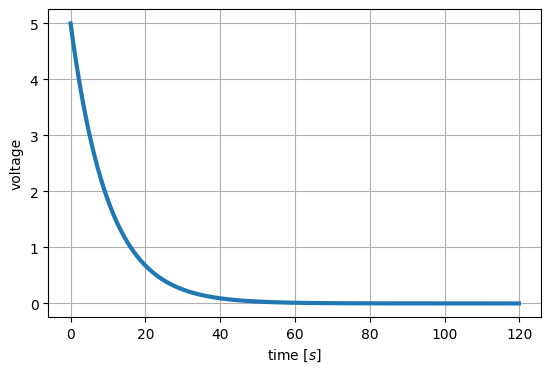

In [18]:
V0 = 5        # 5V
R = 10000     # 10 Kohm
C = 0.001     # 1000 micro farads

t = np.arange(0, 120, 0.1)    
v = V0 * np.exp(-t/(R * C))   

plot_response(t, v, 'voltage', 'C0', (1, 2, 1))

### The discretized RC lowpass
<img src="img/rc.png" alt="Drawing" style="float: right; width: 300px; margin: 0px 30px;"/>

 * current on resistor and capacitor is the same
 * $q[n]$: charge on the capacitor at interval $n$
 * capacitor current in a discrete step
   $$
       i[n] = \frac{q[n] - q[n-1]}{T} = \frac{C}{T}(v_o[n] - v_o[n-1])
   $$
 * Ohm's law: $v_i[n] = Ri[n] + v_o[n]$


again, we obtain a leaky integrator!
$$
    v_o[n] = (1-\lambda) v_i[n] + \lambda v_o[n-1] \qquad \lambda = 1 / (1 + T/RC)
$$

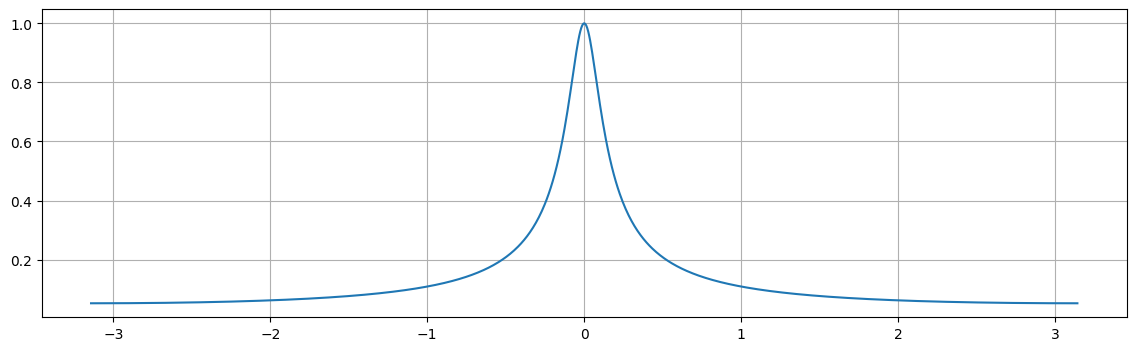

In [19]:
lam=0.9
w, h = signal.freqz(1-lam, [1, -lam], worN=np.linspace(-np.pi, np.pi, 1001))
plt.plot(w, np.abs(h))
plt.grid()

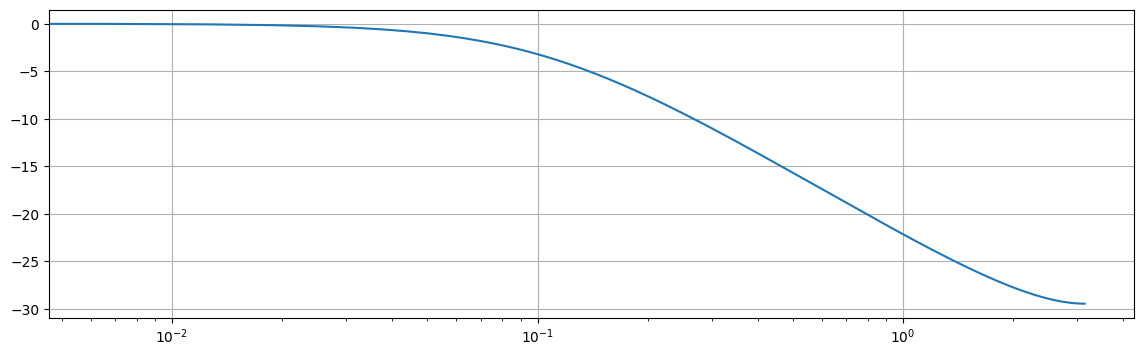

In [20]:
plt.semilogx(w, 10 * np.log(np.abs(h)))
plt.grid()

# How do we fix the transoceanic cable?

To widen the bandwidth of the transmission line we need to "pull up" the transfer function. How can we do it?

 * the modern way: use amplifiers and build **active** filters with gains > 1
 * in the early days: use **inductors** and build passive RLC filters

## The inductor

<img src="img/inductor.jpg" alt="Drawing" style="float: right; width: 300px; margin: 0px 30px;"/>

An inductor is an electronic device that can **store** energy by creating a magnetic field.

$$ E_L = \frac{1}{2}LI^2 $$

### Dynamic behavior

An inductor tries to "resist" changes in current flow by generating an opposing voltage:

$$
    v(t) = -L i'(t)
$$

### Hydraulic analogy

<img src="img/inductor.png" alt="Drawing" style="width: 400px; margin: 100px 0 0 300px;"/>


### Inductive reactance
<img src="img/inductance.jpg" alt="Drawing" style="float: right; width: 400px; margin: 0px 30px;"/>

An inductor also acts as a frequency-dependent resistor:
 * at low frequencies an inductor acts like a wire
 * at high frequencies an inductor acts like a large resistor
 * miraculously, this is the inverse behavior of a capacitor (thank you Maxwell!)
 
OK, but how does this help us "lift up" the frequency response?

### Intuition: resonance in an LC circuit (tank circuit)

<img src="img/lctank.jpg" alt="Drawing" style="height: 400px;"/>





 * natural frequency of the system $\omega_0 = 1/\sqrt{LC}$
 * amplitude of the oscillation: depending on the amount of initial charge
 * if a little charge is repetedly added _at the right times_ , amplitude increases indefinitely because no energy is lost
 * of course in reality there are losses

### Hydraulic analogy for the LC tank circuit

<img src="img/LChydraulic.png" alt="Drawing" style="width: 400px; margin: 0px 30px;"/>


### Digression: Resonance

How can a physical system store energy? Static methods:
  * as chemical bonds (batteries, food, fuel)
  * as potential energy (dams)
  * as thermal energy (liquid gas)
  * ...
 
 
A **resonant system** stores energy by alternately transferring it between different forms of storage:
  * pendulum (kinetic vs. potential)
  * vibrating string (kinetic vs. tensional)
  * LC circuit (electric vs magnetic field)
  * ...

#### Resonance frequency

The cadence of the internal energy transfer is called the natural frequency of a resonant system. 

Input energy at or near the resonant frequency will be absorbed by the system easily (and conversely). 

#### Resonance and complex poles

The transfer function of a LTI resonant system necessarily has complex poles. Why?

  * the impulse response of a LTI system is always a linear combination of decaying exponentials 
  * each exponential corresponds to a pole
  * the resonant mechanism has an oscillatory component: the exponential must be complex

### The RLC lowpass filter

<img src="img/rlc.jpg" alt="Drawing" style="float: right; width: 400px; margin: 0px 30px;"/>

$$
    V_\mathrm{out}(s) = \frac{1}{LCs^2 + RCs + 1}V_\mathrm{in}(s)
$$

 * second order filter
 * resonant frequency $\omega_0 = 1/\sqrt{LC}$
 * peak amplitude $Q = \frac{1}{R}\sqrt{\frac{L}{C}}$
 * no peak for $Q \le 1/\sqrt{2}$

 * -40 dB/decade (twice the rolloff of an RC)
 * resonance peak if poles are complex-valued

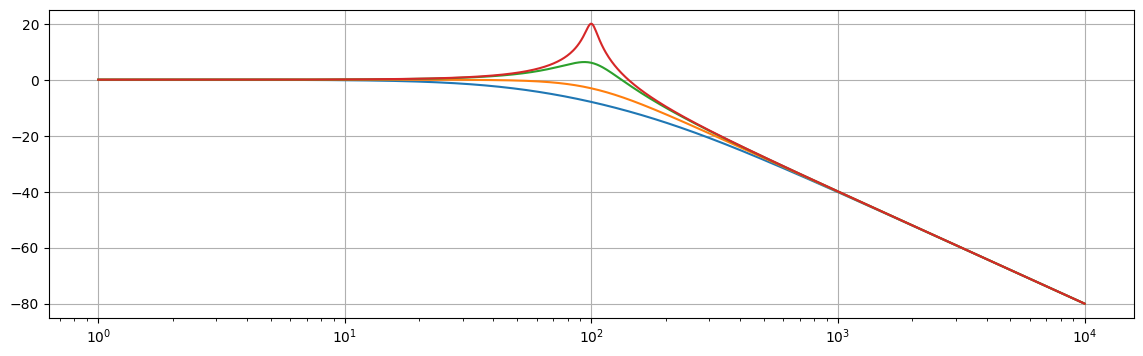

In [21]:
plt.semilogx(*signal.bode(([1], [(1/100)**2, 1/40, 1]), w=np.logspace(0, 4, 1000))[:2]);
plt.semilogx(*signal.bode(([1], [(1/100)**2, 1/70, 1]), w=np.logspace(0, 4, 1000))[:2]);
plt.semilogx(*signal.bode(([1], [(1/100)**2, 1/200, 1]), w=np.logspace(0, 4, 1000))[:2]);
plt.semilogx(*signal.bode(([1], [(1/100)**2, 1/1000, 1]), w=np.logspace(0, 4, 1000))[:2]);
plt.grid();

### "Pulling up" a transmission line

How to use a RLC lowpass to double the bandwidth of a fixed RC-like transmission line:

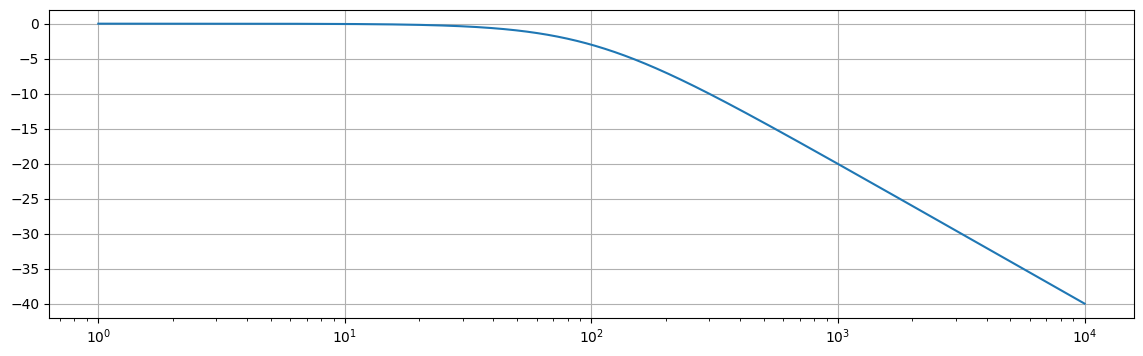

In [27]:
rc_lp = [1/100, 1]
plt.semilogx(*signal.bode(([1], rc_lp), w=np.logspace(0, 4, 1000))[:2]);
plt.grid();

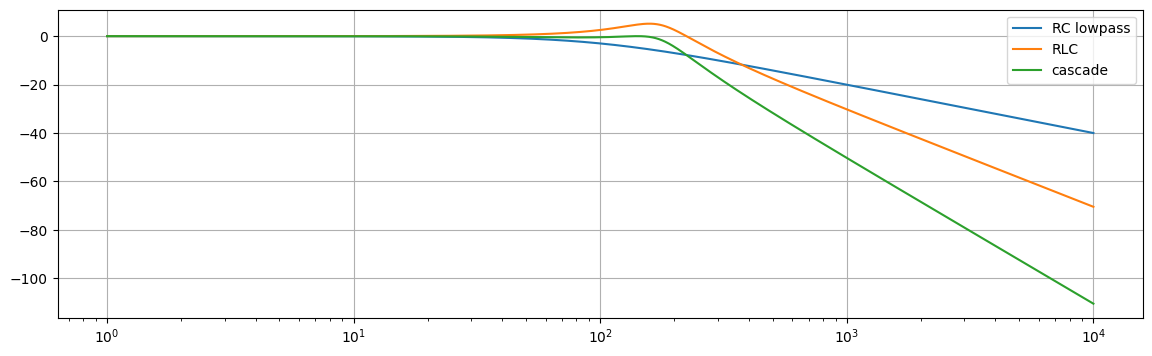

In [28]:
rlc_lp = [1/30000, 1/300, 1]
plt.semilogx(*signal.bode(([1], rc_lp), w=np.logspace(0, 4, 1000))[:2], label="RC lowpass");
plt.semilogx(*signal.bode(([1], rlc_lp), w=np.logspace(0, 4, 1000))[:2], label="RLC");
# cascading filters multiplies the transfer functions, which is equivalent to polynomial multiplication
plt.semilogx(*signal.bode(([1], np.polymul(rc_lp, rlc_lp)), w=np.logspace(0, 4, 1000))[:2], label="cascade");
plt.grid();
plt.legend();

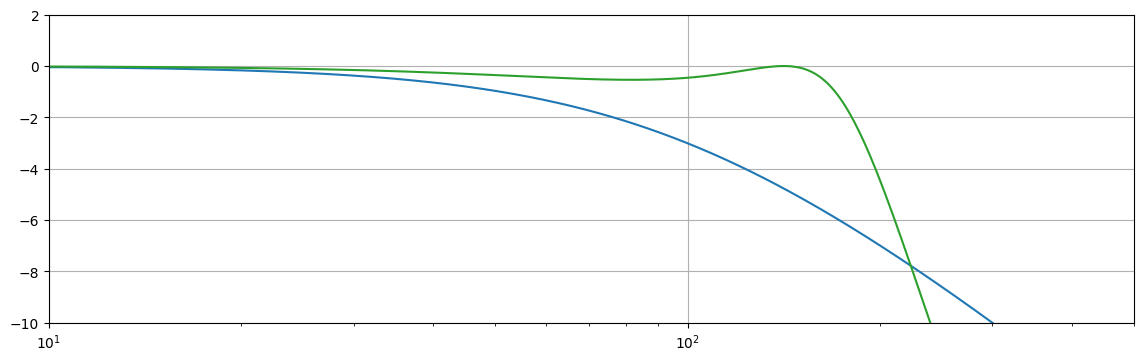

In [29]:
plt.semilogx(*signal.bode(([1], rc_lp), w=np.logspace(0, 4, 1000))[:2]);
plt.semilogx(*signal.bode(([1], np.polymul(rc_lp, rlc_lp)), w=np.logspace(0, 4, 1000))[:2], 'C2');
plt.xlim(10, 500)
plt.ylim(-10, 2)
plt.grid();

In practice, inductors called **loading coils** were spliced up every few km in telephone lines to flatten the bandwidth. As a side effect, traditional telephone lines have a cutoff at 4 kHz.

<img src="img/loadingcoil.jpg" alt="Drawing" style="float: left; height: 200px; margin: 0px 0px;"/>


### The RLC second-order sections

A RLC filter can be designed to be:
  * lowpass
  * highpass
  * bandpass (in the limit: resonator)
  * bandstop (int the limit: notch)
  * allpass
  
Second order sections can be cascaded to implement higher-order filters. But passive analog sections are not decoupled, so it's a bit tricky.

## Active Electronic Filters

Active filters use amplifying elements (tubes, transistors, op-amps, etc)

 * no need for inductors 
 * gain larger than unity
 * decoupling between cascaded sections
 
But
 * need power supply
 * limited to low-voltage applications (eg, still need passive filters in loudspeaker crossover filters)

### The active second-order lowpass

<img src="img/activelowpass.jpg" alt="Drawing" style="float: right; width: 400px; margin: 0px 30px;"/>

$$
    V_\mathrm{out}(s) = \frac{1}{a_2 s^2 + a_1 s + 1}V_\mathrm{in}(s)
$$

 * second order filter
 * resonant frequency $\omega_0 = 1/\sqrt{R_1 R_2 C_1 C_2}$
 * peak amplitude $Q = \sqrt{R_1 R_2 C_1 C_2}/(C_2(R_1 + R_2))$
 * no peak for $Q \le 1/\sqrt{2}$

### The active second-order section

<img src="img/towthomas.jpg" alt="Drawing" style="float: right; width: 400px; margin: 0px 30px;"/>

$$
    V_\mathrm{out}(s) = \frac{b_2 s^2 + b_1 s + b_0}{a_2 s^2 + a_1 s + 1}V_\mathrm{in}(s)
$$

Very complicated relation between transfer function coefficients and component ratings. 

<img src="img/biquad.png" alt="Drawing" style="float: right; width: 400px; margin: 20px 30px;"/>

# Luckily, we prefer DSP!

Digital biquad sections provide:
 * the ability to replicate every analog designs 
 * all the advantages of active filters 
 * superior precision (no discrete components)
 * complete decoupling in cascade realizations
 * fully customizable second-order transfer functions